In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

In [2]:
# Load dataset
df = pd.read_csv("./osteoporosis.csv")
df.head()
# Drop unused column
df.drop("Id", axis=1, inplace=True)

# Fill missing values
df["Alcohol Consumption"].fillna("None", inplace=True)
df["Medical Conditions"].fillna("None", inplace=True)
df["Medications"].fillna("None", inplace=True)

df.head()

,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,None,None,None,Yes,1
2,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,None,Rheumatoid Arthritis,Corticosteroids,No,1
4,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,None,Rheumatoid Arthritis,None,Yes,1


In [3]:
# Encoding categorical variables and scaling
le_dict = {}  # To save label encoders for each column
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

# Save the encoding using pickle
with open('label_encoded_dict.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

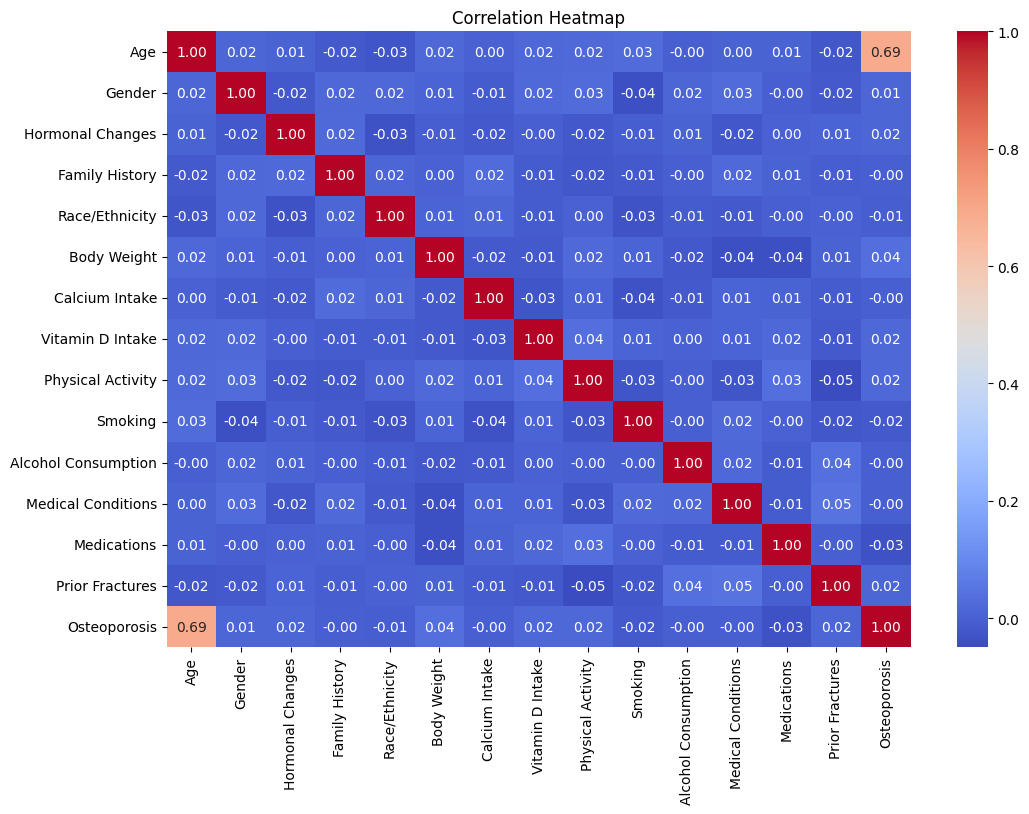

In [4]:
# Compute correlation matrix
correlation_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [5]:
print(correlation_matrix['Osteoporosis'])

Age                    0.691238
Gender                 0.012258
Hormonal Changes       0.015322
Family History        -0.002043
Race/Ethnicity        -0.006826
Body Weight            0.035794
Calcium Intake        -0.004087
Vitamin D Intake       0.017374
Physical Activity      0.019425
Smoking               -0.016343
Alcohol Consumption   -0.002043
Medical Conditions    -0.003122
Medications           -0.033708
Prior Fractures        0.015322
Osteoporosis           1.000000
Name: Osteoporosis, dtype: float64


Based on the correlation coefficients between Osteoporosis and other features, I will be using features with higher absolute correlation values, as they have a stronger linear relationship with the target variable Osteoporosis. Here are the features with relatively higher absolute correlation coefficients:

<ul>
    <li>Age: 0.691238</li>
    <li>Body Weight: 0.035794</li>
    <li>Physical Activity: 0.019425</li>
    <li>Hormonal Changes: 0.015322</li>
    <li>Vitamin D Intake: 0.017374</li>
    <li>Prior Fractures: 0.015322</li>
</ul>


In [6]:
df.head()

,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,69,0,0,1,1,1,1,1,1,1,0,2,0,1,1
1,32,0,0,1,1,1,1,1,1,0,1,1,1,1,1
2,89,0,1,0,2,0,0,1,0,0,0,0,0,0,1
3,78,0,0,0,2,1,0,0,1,1,1,2,0,0,1
4,38,1,1,1,0,0,1,1,0,1,1,2,1,1,1


In [7]:
scaler = MinMaxScaler()
df.iloc[:, :-1] = scaler.fit_transform(df.iloc[:, :-1])  # Exclude target column for scaling

# Save the scaler using pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Train-test split
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


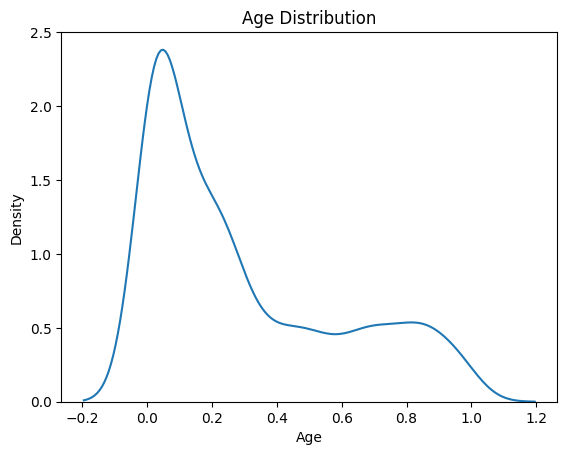

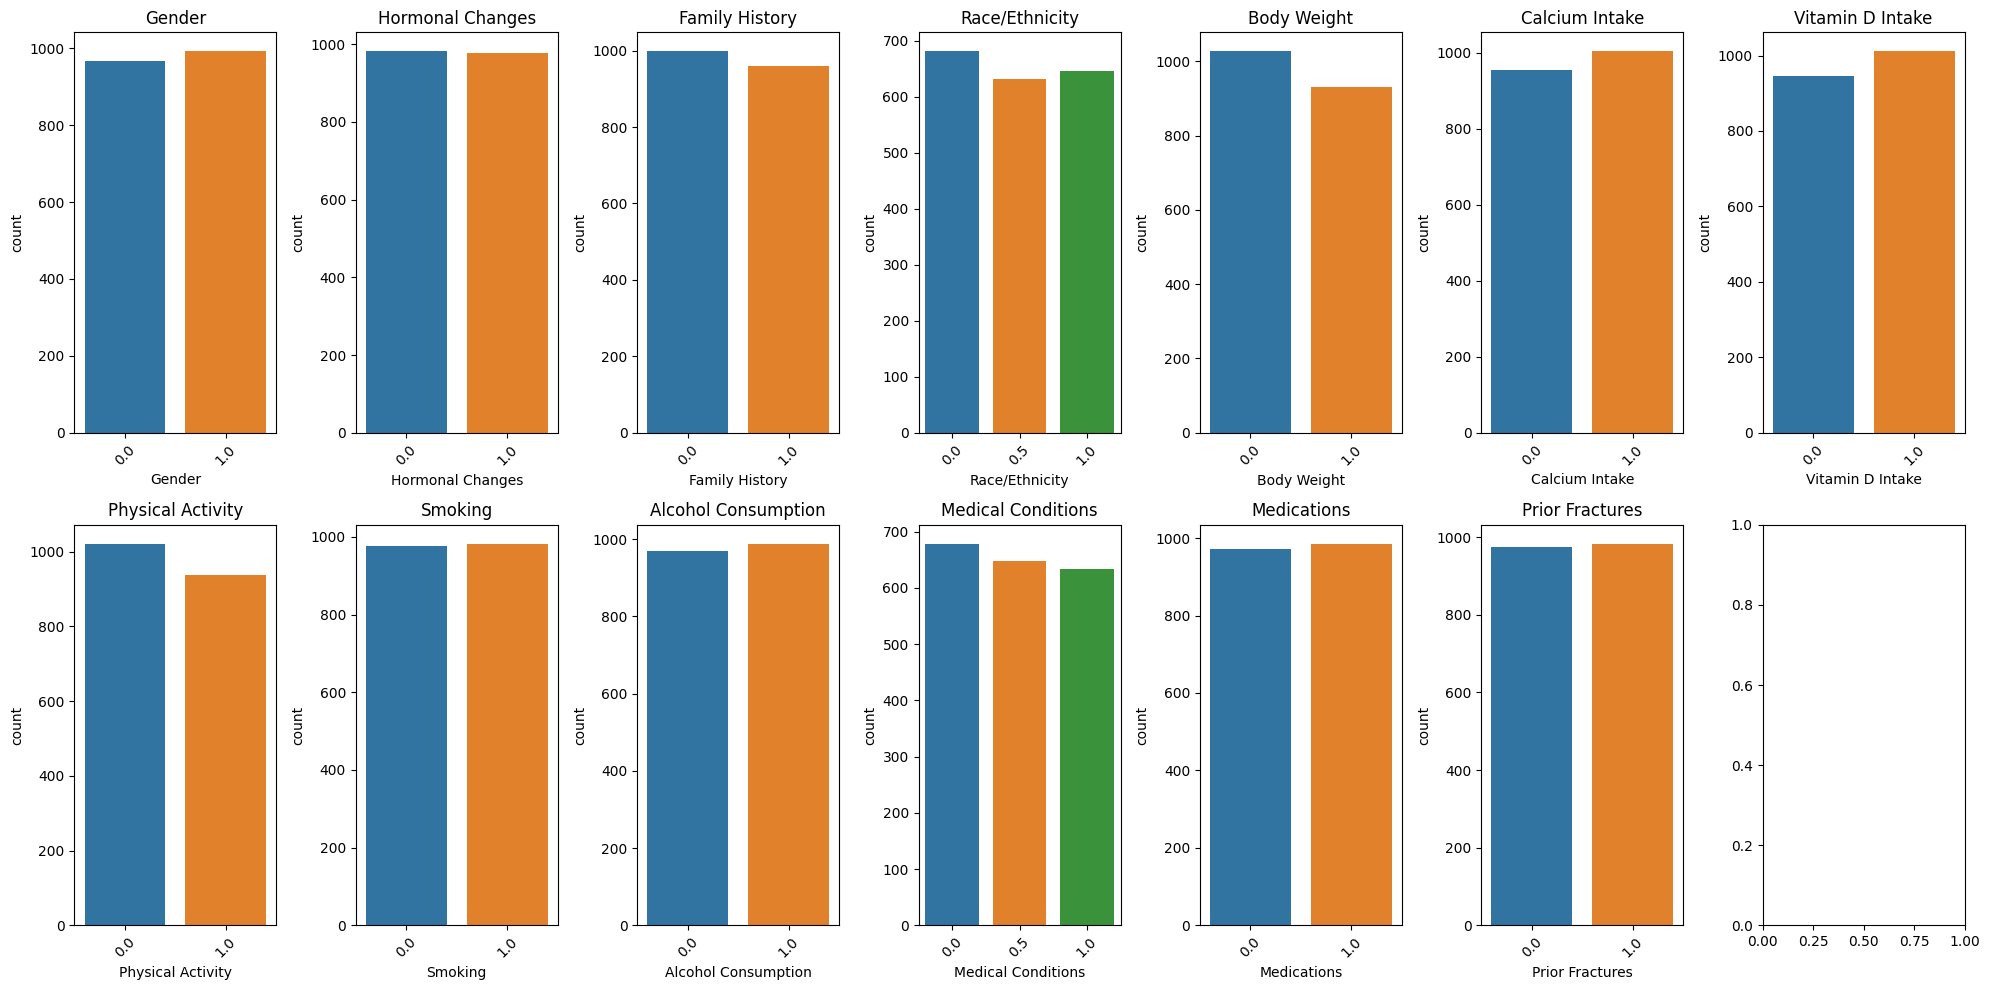

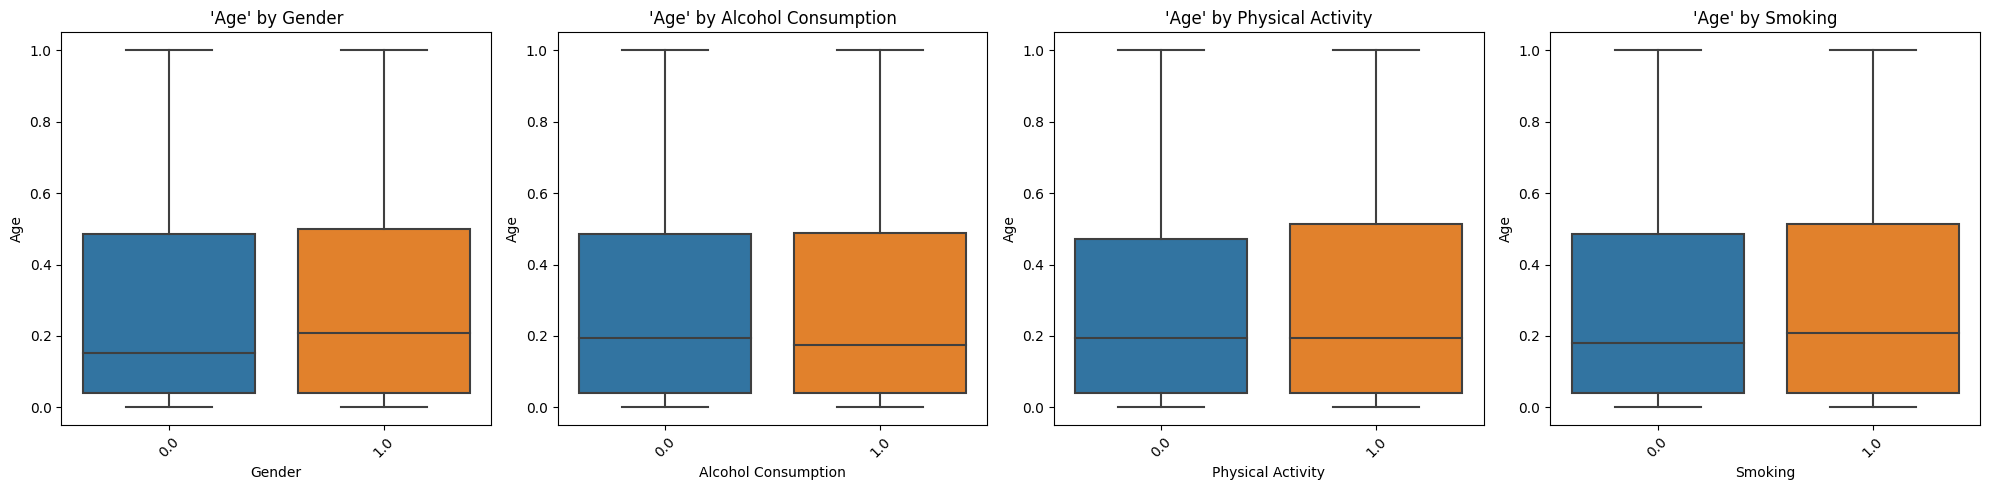

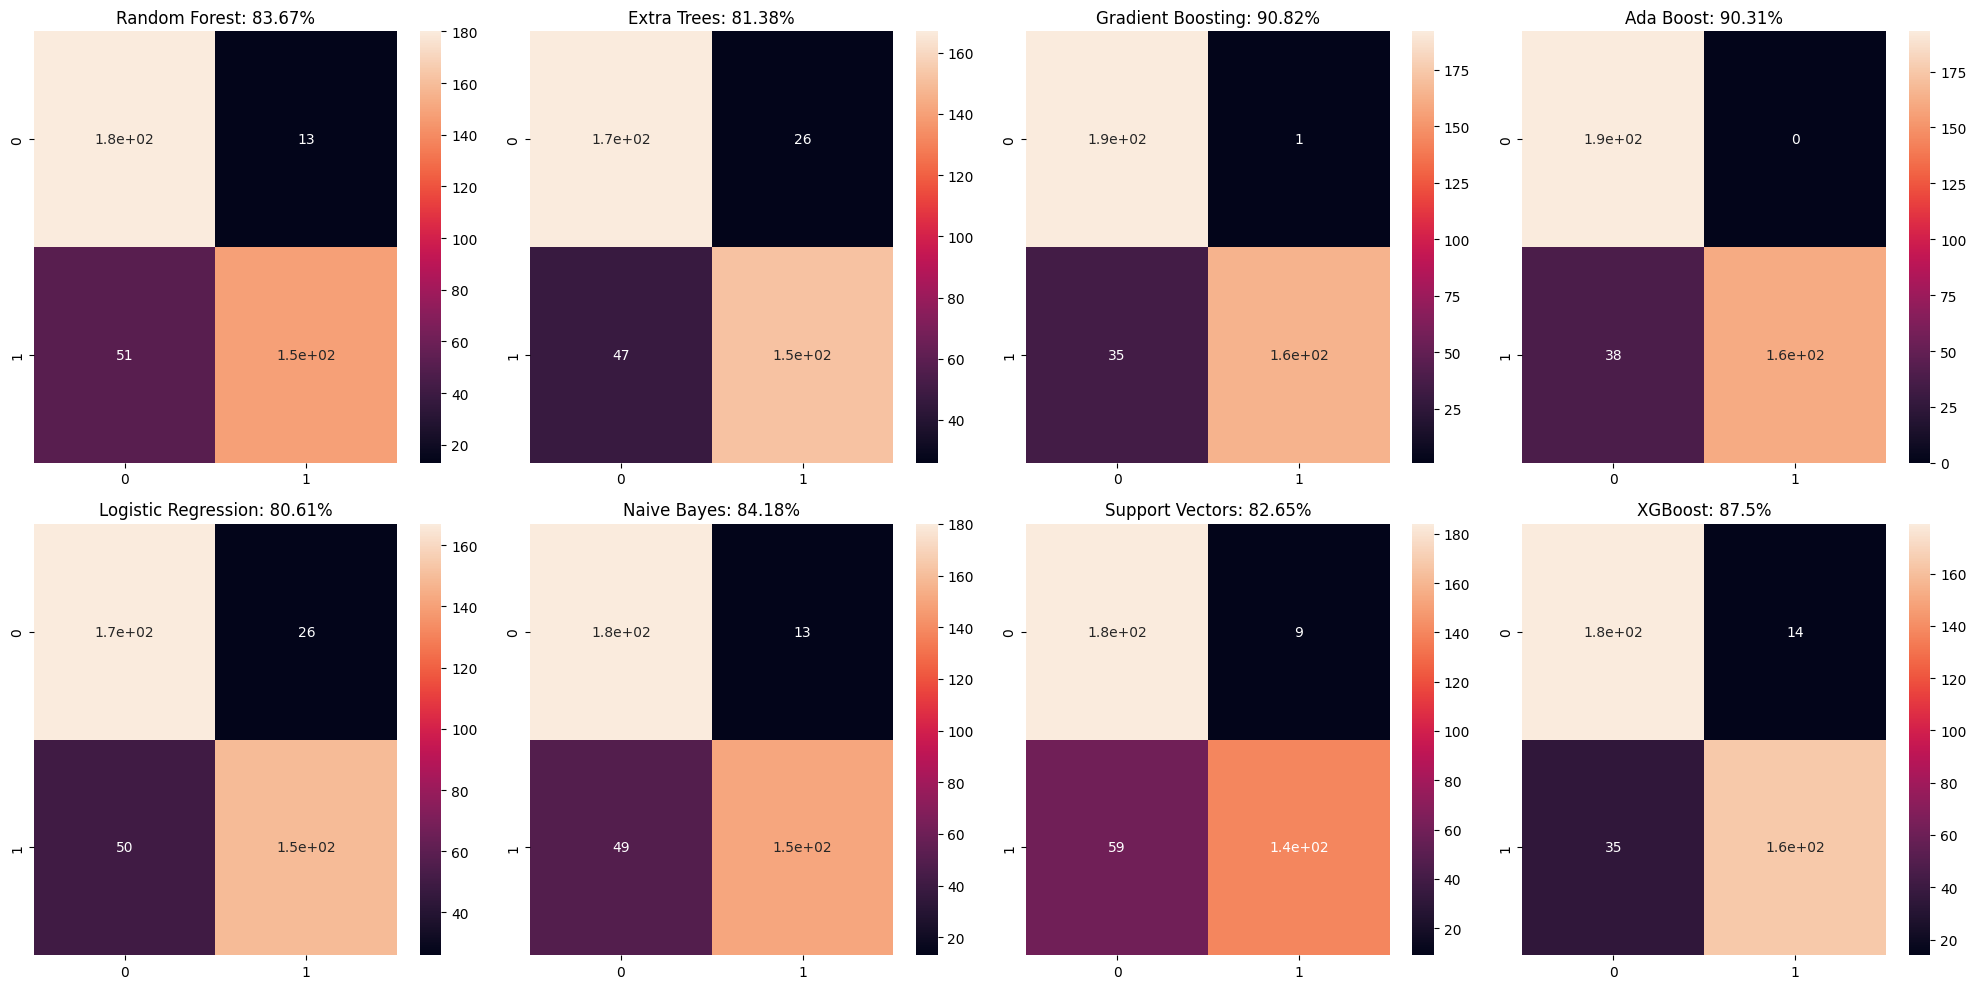

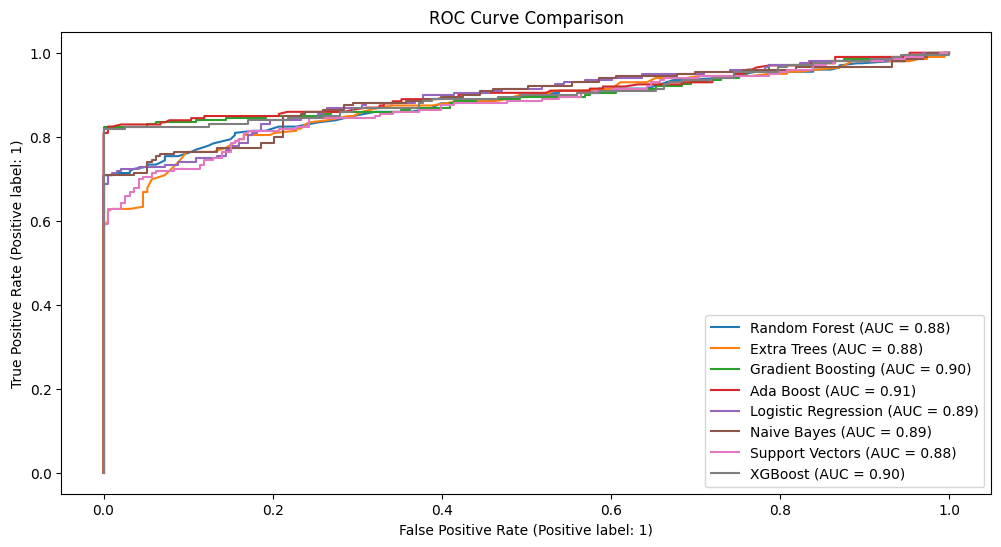

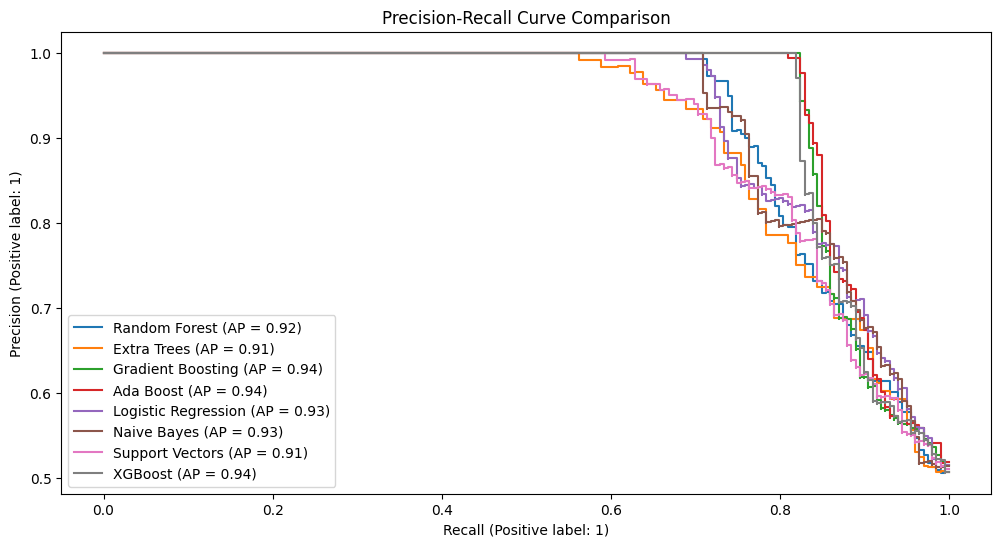

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from xgboost import XGBClassifier

# Initial visualizations for understanding the data
sns.kdeplot(df['Age'])
plt.title("Age Distribution")
plt.show()

# Count plots for each categorical variable
fig, axes = plt.subplots(nrows=2, ncols=7, figsize=(20, 10))
index = 1
for i in range(2):
    for j in range(7):
        sns.countplot(data=df, x=df.columns[index], ax=axes[i][j])
        axes[i][j].set_title(df.columns[index])
        axes[i][j].tick_params(axis='x', rotation=45)
        index += 1
        if index >= len(df.columns) - 1:  # Avoid plotting the target variable
            break
plt.tight_layout()
plt.show()

# Box plots for numerical data against categories
category_columns = ['Gender', 'Alcohol Consumption', 'Physical Activity', 'Smoking']
ncols = len(category_columns)
fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(5 * ncols, 5))  # Adjust figure size as needed
for i, cat_col in enumerate(category_columns):
    sns.boxplot(data=df, x=cat_col, y='Age', ax=axes[i])  # Plot 'Age' against each category column
    axes[i].set_title(f"'Age' by {cat_col}")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Parallel Categories Diagram for categorical variables
#for cat_col in category_columns:
#    fig = px.parallel_categories(df[[cat_col, 'Osteoporosis']], color="Osteoporosis", color_continuous_scale=px.colors.sequential.Inferno)
#    fig.show()

# Model training and comparison
models = [RandomForestClassifier(), ExtraTreesClassifier(), GradientBoostingClassifier(), AdaBoostClassifier(),
          LogisticRegression(), GaussianNB(), SVC(), XGBClassifier()]
names = ["Random Forest", "Extra Trees", "Gradient Boosting", "Ada Boost", "Logistic Regression", "Naive Bayes",
         "Support Vectors", "XGBoost"]

def training(model, name, axes):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = accuracy_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, ax=axes)
    axes.set_title("{}: {}%".format(name, round(score*100, 2)))
    return score*100, classification_report(y_test, pred)

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
index = 0
scores = []
reports = []
for i in range(2):
    for j in range(4):
        score, report = training(models[index], names[index], axes[i][j])
        scores.append(score)
        reports.append(report)
        index += 1
plt.tight_layout()
plt.show()

# Enhanced Visualizations: ROC Curve and Precision-Recall Curve Comparison
plt.figure(figsize=(12, 6))
for model, name in zip(models, names):
    model_trained = model.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(model_trained, X_test, y_test, ax=plt.gca(), name=name)
plt.title("ROC Curve Comparison")
plt.show()

plt.figure(figsize=(12, 6))
for model, name in zip(models, names):
    model_trained = model.fit(X_train, y_train)
    PrecisionRecallDisplay.from_estimator(model_trained, X_test, y_test, ax=plt.gca(), name=name)
plt.title("Precision-Recall Curve Comparison")
plt.show()


Model Accuracy: 90.82%
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.91       193
           1       0.99      0.82      0.90       199

    accuracy                           0.91       392
   macro avg       0.92      0.91      0.91       392
weighted avg       0.92      0.91      0.91       392



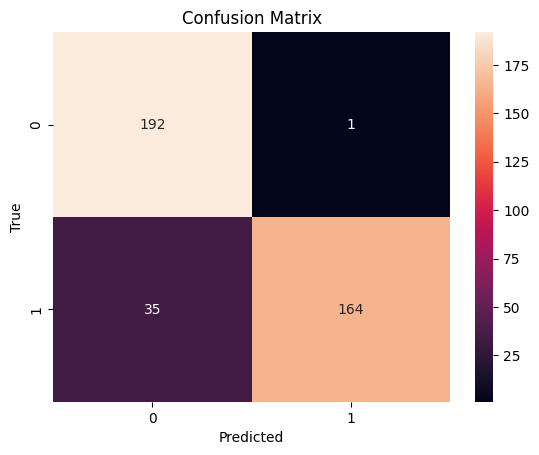

In [9]:
from sklearn.ensemble import GradientBoostingClassifier
import joblib

# Training the Gradient Boosting Classifier
gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train)

# Saving the trained model for later use
joblib.dump(gbc, 'gradient_boosting_classifier.joblib')

# Function to extract confidence scores
def get_confidence_scores(model, data):
    # Get probability predictions for each class
    probs = model.predict_proba(data)
    # Assuming the positive class (Osteoporosis) is at index 1
    return probs[:, 1]

# Model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Making predictions on the test set
y_pred = gbc.predict(X_test)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2%}')

# Generating a classification report
report = classification_report(y_test, y_pred)
print('Classification Report:\n', report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [10]:
import numpy as np

# Creating a synthetic test input (ensure this matches the shape and preprocessing of your real input data)
# Here, we're creating a single test instance with features similar to those in your dataset
test_input = np.array([[0.5,0.1, 0.1, 0.1, 0.1, 0.2, 0.7, 0.3, 0.6, 0.1, 0.8, 0.4, 0.9, 0.0]])  # Example feature values

# Making a prediction with the Gradient Boosting Classifier
predicted_class = gbc.predict(test_input)
predicted_label = 'Osteoporosis' if predicted_class[0] == 1 else 'No Osteoporosis'

# Extracting the confidence score for the prediction
confidence_score = get_confidence_scores(gbc, test_input)[0]  # Get the confidence score for the positive class

# Output the prediction and confidence score
print(f"Predicted Label: {predicted_label}")
print(f"Confidence Score: {confidence_score:.2f}")


Predicted Label: Osteoporosis
Confidence Score: 1.00


In [11]:
gbc.classes_

array([0, 1], dtype=int64)

In [12]:
gbc.predict(test_input)

array([1], dtype=int64)

In [13]:
gbc.predict_proba(test_input)

array([[0.00170041, 0.99829959]])